## Tarea 1. Diseña una base de datos Cassandra para dar servicio a las lecturas y escrituras anteriores. Argumenta tus decisiones de diseño. 

### 1. Hall of fame


El “hall of fame” de cada país, es decir, para un país concreto se muestran para cada mazmorra del juego el TOP 5 de jugadores 
más rápidos de ese país, incluyendo sus tiempos.

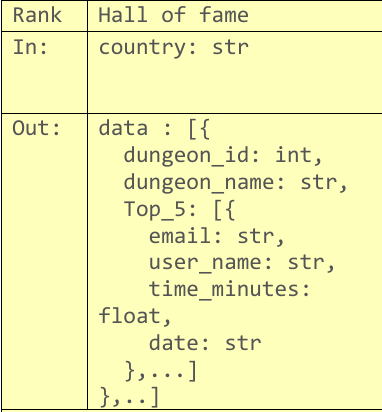

**NOTA**: Así es como considero que podría hacerse. Por el enunciado, es posible que dungeon_id no sea parte de la clave de partición, sino de clustering. Tener eso en cuenta. Podemos preguntar. 

Como es necesario mostrar para cada país concreto, entonces esta debe ser parte de la clave de partición. Además de eso, asumimos por el enunciado que se deberá filtrar también el el id de la mazmorra (o el nombre en caso de que sea único), por lo que este también tiene que formar parte de la clave de partición. Así, las consultas se resuelven en un sólo nodo. 

Como queremos tener un orden teniendo en cuenta el tiempo, será necesario dentro de la partición de cada país-mazmorra definir claves de clustering. Para las claves de clustering, tendremos el tiempo (ordenado de manera ascendente, de menor a mayor, ya que queremos que aparezcan primero los jugadores con los menores tiempos). Como puede ser que varios jugadores hayan hecho el mismo tiempo, añadiremos el email (que según el esquema E/R es la clave primaria del jugador) para poder garantizar unicidad de la fila (así evitamos que un tiempo igual de otro usuario sobreescriba el registro). Estos últimos serán en orden ascendente (por orden alfabético)

Aunque nos pida el TOP 5, simplemente escogemos todos y ya nos encargaremos que la aplicación lea sólamente las 5 primeras filas (usando LIMIT 5). 

Para el resto de datos que aparecen en el enunciado, tendremos que incluirlos dentro de la tabla: 

- user_name
- date
- dungeon_name

Para resumir, el esquema general de la tabla sería el siguiente: 

**Nombre de la tabla**: hall_of_fame
- **Partition Key**: (country, dungeon_id)
- **Clustering Columns**: (time_minutes ASC, email ASC)
- **Otras columnas**: 
    - user_name
    - date
    - dungeon_name

En Cassandra: 


```sql
CREATE TABLE hall_of_fame (
    country TEXT,
    dungeon_id INT,
    time_minutes FLOAT,
    email TEXT,
    user_name TEXT,
    date TEXT,
    dungeon_name TEXT STATIC,
    PRIMARY KEY ((country, dungeon_id), time_minutes, email)
) WITH CLUSTERING ORDER BY (time_minutes ASC, email ASC);


# TODO: justificar los tipos dentro de la tabla

### 2. User Statistics

.. y las estadísticas de un jugador, que muestra 
los tiempos que ha tardado en completar una mazmorra en particular ordenados de menor a 
mayor.  

Como tiene como entradas el id del usuario y el id de la mazmorra, simplemente podemos tener como clave de partición ambos atributos para poder garantizar un acceso directo a los intentos de un usuario específico para una mazmorra en concreto. 

Al igual que en el ejemplo anterior, para la clave de clustering conviene utilizar el tiempo en minutos y en orden ascendente, ya que queremos que los mejores tiempos aparezcan antes. **NOTA**: en caso de que haya dos tiempos iguales, para poder diferenciarlos, podemos usar la fecha, aunque si no simplemente no pasa nada. 

Como también se nos pide la fecha (en caso de que sea clave de clustering no será necesario), tendremos que incluirlo dentro de la tabla. 

**Nombre de la tabla**: user_statistics
- **Partition Key**: (user_id, dungeon_id)
- **Clustering Columns**: (time_minutes ASC, date ASC)
- **Otras columnas**: 

```sql
CREATE TABLE user_statistics_by_dungeon (
    user_id int,
    dungeon_id int,
    time_minutes float,
    date text,
    PRIMARY KEY ((user_id, dungeon_id), time_minutes, date)
) WITH CLUSTERING ORDER BY (time_minutes ASC, date ASC);